### Import Modules


In [1]:
# Standard Library
import random, traceback
from collections.abc import Callable, Generator
from contextlib import contextmanager
from datetime import datetime, timezone
from IPython.display import display
from pathlib import Path
from typing import Any

# Packages
import mlflow, numpy, optuna, pandas, torch
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from matplotlib import pyplot, ticker
from matplotlib.figure import Figure
from mlflow import ActiveRun, MlflowClient
from mlflow.models import infer_signature, ModelSignature
from mlflow.models.model import ModelInfo
from mlflow.pyfunc import PythonModel, PythonModelContext
from numpy import ndarray
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from torch import multiprocessing, nn, optim, Tensor
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from xgboost import XGBClassifier

C:\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants & Config


In [2]:
# Paths
ROOT_DIR = Path("../").resolve()

# Data
TEST_SIZE = 0.2
START_DATE = datetime(2013, 9, 1, tzinfo=timezone.utc)
SEED_PATH = (
    ROOT_DIR
    / "database"
    / "seed"
    / "transaction_inferences"
    / "creditcard_transactions.csv.gz"
)

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
numpy.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Cross Validation
CV_VAL_SIZE = TEST_SIZE / (1 - TEST_SIZE)
CV = StratifiedKFold(
    n_splits=int(1 / CV_VAL_SIZE), shuffle=True, random_state=RANDOM_STATE
)

# Hyperparameter Optimization
BAYES_STEPS = 30
TRAINING_TIMEOUT_SECONDS = 3_600
ACTIVATION_MAP = {"relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU}

# Torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE.type}")
multiprocessing.set_start_method("spawn", force=True)

# optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# MLflow
MLFLOW_DIR = Path("./mlflow").resolve()
MLFLOW_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(MLFLOW_DIR / "mlflow.db").as_posix()}")
EXPERIMENT_NAME = "fraud-detection"
if not mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=(MLFLOW_DIR / "artifacts").as_uri(),
    )
mlflow.set_experiment(EXPERIMENT_NAME)

Device: cpu


<Experiment: artifact_location='file:///C:/Projects/Personal/Practice/fraud-detection-platform/notebooks/mlflow/artifacts', creation_time=1790937425064, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790937425064, lifecycle_stage='active', name='fraud-detection', tags={}, trace_location=None, workspace='default'>

### Helpers: Evaluation


In [3]:
def get_predictions_pyfunc(
    model: PythonModel,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    return {
        "y_pred": model.predict(None, x, params={"threshold": threshold}),
        "y_prob": model.predict(None, x, params={"probabilities": True})[:, 1],
    }

def get_predictions_pipeline(
    model: Pipeline,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    y_prob = model.predict_proba(x)[:, 1]
    return {
        "y_pred": (y_prob >= threshold).astype(int),
        "y_prob": y_prob
    }

In [4]:
def evaluate_model_predictions(
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
) -> dict[str, float]:
    return {
        "F1 score": f1_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

def visualize_model_predictions(
    title: str,
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
    threshold: float = 0.5,
) -> dict[str, Figure]:
    confusion_matrix_figure, confusion_matrix_ax = pyplot.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Legitimate", "Fraud"],
        normalize="true",
        cmap="Blues",
        values_format=".1%",
        ax=confusion_matrix_ax,
    )
    confusion_matrix_ax.set_title(title)

    probability_scatter_figure, probability_scatter_ax = pyplot.subplots()
    probability_scatter_ax.scatter(
        y_prob,
        range(len(y_true)),
        c=numpy.where(y_true == 1, "red", "blue"),
        edgecolors="k",
    )
    probability_scatter_ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    probability_scatter_ax.axvline(
        x=threshold, alpha=0.3, color="white", linestyle="--"
    )
    probability_scatter_ax.axvspan(threshold, 1.0, alpha=0.05, color="red")
    probability_scatter_ax.axvspan(0.0, threshold, alpha=0.05, color="blue")
    probability_scatter_ax.set_yticks([])
    probability_scatter_ax.set_ylabel("Transactions")
    probability_scatter_ax.set_xlabel("Fraud Probability Score")
    probability_scatter_ax.set_title(title)

    return {
        f"probability_scatter_{title.lower()}": probability_scatter_figure,
        f"confusion_matrix_{title.lower()}": confusion_matrix_figure,
    }

def evaluate_model(
    *,
    model: Pipeline | PythonModel,
    model_input: ndarray,
    y_true: ndarray,
    title: str,
) -> tuple[dict[str, ndarray], dict[str, float], dict[str, Figure]]:
    predictions = (
        get_predictions_pyfunc(model, model_input)
        if isinstance(model, PythonModel)
        else get_predictions_pipeline(model, model_input)
    )
    metrics = evaluate_model_predictions(**predictions, y_true=y_true)
    figures = visualize_model_predictions(**predictions, y_true=y_true, title=title)
    return predictions, metrics, figures

### Helpers: Tuning


In [5]:
def optimize_hyperparameters(
    objective: Callable[[optuna.Trial], float],
    multivariate: bool,
) -> optuna.Study:
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(
            seed=RANDOM_STATE,
            multivariate=multivariate,
        ),
    )
    study.optimize(
        objective,
        n_trials=BAYES_STEPS,
        n_jobs=1,
        show_progress_bar=True,
        gc_after_trial=True,
        timeout=TRAINING_TIMEOUT_SECONDS,
    )
    return study

### Helpers: MLflow


In [6]:
@contextmanager
def transactional_mlflow_run(run_name: str) -> Generator[ActiveRun, Any, None]:
    with mlflow.start_run(run_name=run_name) as run:
        try:
            yield run
        except Exception:
            run_id_str = str(run.info.run_id)
            client = MlflowClient()
            mlflow.delete_run(run_id_str)
            try:
                versions = client.search_model_versions(f"run_id='{run_id_str}'")
                for version in versions:
                    client.delete_model_version(
                        name=version.name,
                        version=version.version,
                    )
            except Exception:
                pass
            traceback.print_exc()

def log_model_run(
    *,
    model: Pipeline | PythonModel,
    registered_model_name: str,
    signature: ModelSignature,
    input_example: ndarray,
    pip_requirements: list[str],
    params: dict[str, object],
    metrics: dict[str, float],
    figures: dict[str, Figure],
    skops_trusted_types: list[str] | None = None,
) -> ModelInfo:
    if isinstance(model, Pipeline):
        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            skops_trusted_types=skops_trusted_types,
            pyfunc_predict_fn=model.predict_proba.__name__
        )
    else:
        model_info = mlflow.pyfunc.log_model(
            python_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
        )

    mlflow.log_params(params=params, run_id=model_info.run_id)
    mlflow.log_metrics(
        metrics=metrics,
        run_id=model_info.run_id,
        model_id=model_info.model_id,
    )
    for figure_name, figure in figures.items():
        pyplot.show()
        mlflow.log_figure(figure, f"{figure_name}.png")
        pyplot.close(figure)
    return model_info

### Load Data


In [7]:
seed_df = pandas.read_csv(
    SEED_PATH,
    compression="gzip",
    dtype={
        "Time": "float64",
        **{f"V{i}": "float64" for i in range(1, 29)},
        "Amount": "float64",
        "Class": "int8",
    },
)

df = pandas.DataFrame({
    "is_fraud": seed_df["Class"].astype("int64"),
    "transaction_timestamp": (
        START_DATE.timestamp() + seed_df["Time"]
    ).astype("int64"),
    "amount": seed_df["Amount"],
    **{f"v{i}": seed_df[f"V{i}"] for i in range(1, 29)},
})

x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_x_np = train_x.to_numpy(dtype=numpy.float64)
train_y_np = train_y.to_numpy(dtype=numpy.int64)
test_x_np = test_x.to_numpy(dtype=numpy.float64)
test_y_np = test_y.to_numpy(dtype=numpy.int64)

train_x_np_dimensions_size = train_x_np.shape[1]

print(f"Data shape: {df.shape}")
print(f"Train: {train_x.shape}, Test: {test_x.shape}")

Data shape: (284807, 31)
Train: (227845, 30), Test: (56962, 30)


### KNN


C:\Users\MSI Laptop\AppData\Local\Temp\ipykernel_20204\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-02 19:05:43,474] A new study created in memory with name: no-name-2bc72987-1c82-458a-ae34-e11144dbfd24
  0%|          | 0/30 [01:10<?, ?it/s]

[I 2026-10-02 19:06:53,762] Trial 0 finished with value: 0.3624239331373935 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2, 'leaf_size': 69}. Best is trial 0 with value: 0.3624239331373935.


Best trial: 1. Best value: 0.50915:   3%|▎         | 1/30 [02:29<37:51, 78.34s/it, 78.33/3600 seconds] 

[I 2026-10-02 19:08:13,021] Trial 1 finished with value: 0.5091503959692321 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2, 'leaf_size': 103}. Best is trial 1 with value: 0.5091503959692321.


Best trial: 2. Best value: 0.724494:  10%|█         | 3/30 [08:04<1:26:54, 193.13s/it, 484.32/3600 seconds]

...

Best trial: 2. Best value: 0.724494:  57%|█████▋    | 17/30 [1:02:32<47:49, 220.76s/it, 3752.99/3600 seconds]  

[I 2026-10-02 20:08:16,287] Trial 16 finished with value: 0.7244944026945641 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1, 'leaf_size': 63}. Best is trial 2 with value: 0.7244944026945641.


KNN
  Best Hyperparameters: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1, 'leaf_size': 71}


,Metric,Score
0,F1 score,0.722467
1,PR-AUC,0.532159
2,Recall,0.836735
3,Precision,0.635659
4,ROC-AUC,0.917954
5,Accuracy,0.998894


2026/10/02 20:11:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/02 20:12:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'KNN'.
Created version '1' of model 'KNN'.


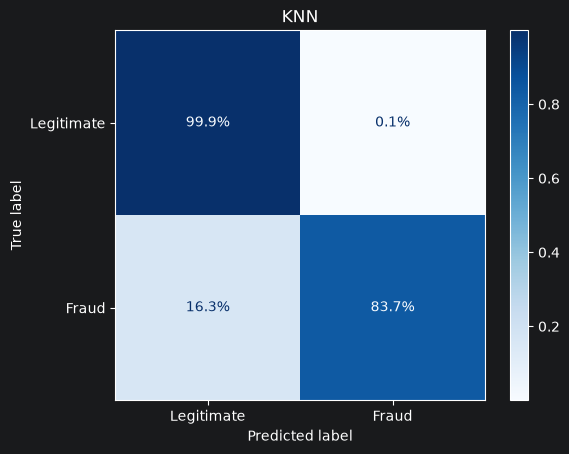

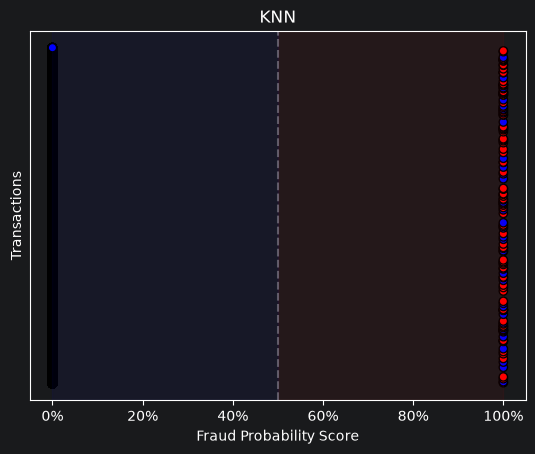

In [8]:
with transactional_mlflow_run(run_name="KNN") as run:
    model_name = "knn"
    run_name_str = str(run.info.run_name)

    def knn_objective(trial: optuna.Trial) -> float:
        knn_params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 1, 30),
            "weights": trial.suggest_categorical(
                "weights", ["uniform", "distance"]
            ),
            "p": trial.suggest_int("p", 1, 2),
            "leaf_size": trial.suggest_int("leaf_size", 60, 120),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                KNeighborsClassifier(**knn_params, n_jobs=-1),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    knn_study = optimize_hyperparameters(
        objective=knn_objective,
        multivariate=True,
    )
    knn_best_params = knn_study.best_params
    knn_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            KNeighborsClassifier(**knn_best_params, n_jobs=-1),
        ),
    ]).fit(train_x_np, train_y_np)
    _, knn_metrics, knn_figures = evaluate_model(
        model=knn_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {knn_best_params}")
    display(pandas.DataFrame(knn_metrics.items(), columns=["Metric", "Score"]))
    knn_model_info = log_model_run(
        model=knn_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=knn_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "sklearn.neighbors._classification.KNeighborsClassifier",
        ],
        params=knn_best_params,
        metrics=knn_metrics,
        figures=knn_figures,
    )

### Random Forest


In [ ]:
with transactional_mlflow_run(run_name="Random_Forest") as run:
    model_name = "rf"
    run_name_str = str(run.info.run_name)

    def rf_objective(trial: optuna.Trial) -> float:
        rf_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 5, 15),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2"]
            ),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                RandomForestClassifier(
                    **rf_params,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=1,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    rf_study = optimize_hyperparameters(
        objective=rf_objective,
        multivariate=True,
    )
    rf_best_params = rf_study.best_params
    rf_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            RandomForestClassifier(
                **rf_best_params,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    _, rf_metrics, rf_figures = evaluate_model(
        model=rf_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {rf_best_params}")
    display(pandas.DataFrame(rf_metrics.items(), columns=["Metric", "Score"]))
    rf_model_info = log_model_run(
        model=rf_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=rf_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.ensemble._forest.RandomForestClassifier",
            "sklearn.tree._classes.DecisionTreeClassifier",
            "sklearn.tree._tree.Tree",
        ],
        params=rf_best_params,
        metrics=rf_metrics,
        figures=rf_figures,
    )

C:\Users\MSI Laptop\AppData\Local\Temp\ipykernel_20204\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-02 20:12:03,109] A new study created in memory with name: no-name-257bb33e-a616-44a1-a30d-3dbba3f06c40
  0%|          | 0/30 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   31.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 175 out of 175 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   28.8s fin

[I 2026-10-02 20:14:03,373] Trial 0 finished with value: 0.7242522600433062 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.5290418060840998}. Best is trial 0 with value: 0.7242522600433062.


Best trial: 0. Best value: 0.724252:   3%|▎         | 1/30 [02:00<58:17, 120.62s/it, 120.62/3600 seconds][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   44.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 274 out of 274 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   44.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 co

[I 2026-10-02 20:17:05,117] Trial 1 finished with value: 0.6319714732464654 and parameters: {'n_estimators': 274, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.6061695553391381}. Best is trial 0 with value: 0.7242522600433062.


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.7s


### XGBoost


In [ ]:
with transactional_mlflow_run(run_name="XGBoost") as run:
    model_name = "xgb"
    run_name_str = str(run.info.run_name)

    def xgb_objective(trial: optuna.Trial) -> float:
        xgb_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.4, 1.0
            ),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                XGBClassifier(
                    **xgb_params,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=2,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    xgb_study = optimize_hyperparameters(
        objective=xgb_objective,
        multivariate=True,
    )
    xgb_best_params = xgb_study.best_params
    xgb_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            XGBClassifier(
                **xgb_best_params,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    _, xgb_metrics, xgb_figures = evaluate_model(
        model=xgb_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {xgb_best_params}")
    display(pandas.DataFrame(xgb_metrics.items(), columns=["Metric", "Score"]))
    xgb_model_info = log_model_run(
        model=xgb_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=xgb_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "xgboost==3.4.1",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier",
        ],
        params=xgb_best_params,
        metrics=xgb_metrics,
        figures=xgb_figures,
    )

### MLP Model


In [ ]:
class MLP(nn.Module):
    def __init__(
        self,
        *,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        activation: str,
        dropout: float,
        epochs: int,
        batch_size: int,
        lr: float,
        weight_decay: float,
        device: torch.device,
    ) -> None:
        super().__init__()
        activation_function = ACTIVATION_MAP[activation]

        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        layer_input_size = input_size
        for _ in range(num_layers):
            self.linears.append(nn.Linear(layer_input_size, hidden_size))
            self.activations.append(activation_function())
            layer_input_size = hidden_size
        self.output = nn.Linear(layer_input_size, 1)

        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.criterion = nn.BCEWithLogitsLoss()
        self.device = device
        self.to(device)
        self.optimizer = optim.AdamW(
            self.parameters(), lr=lr, weight_decay=weight_decay
        )

    def forward(self, x: Tensor) -> Tensor:
        for linear, activation in zip(self.linears, self.activations):
            x = activation(linear(x))
            x = functional.dropout(x, p=self.dropout, training=self.training)
        return self.output(x).squeeze(1)

    def train_one_epoch(self, train_loader: DataLoader) -> float:
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)
            self.optimizer.zero_grad()
            batch_logits = self(batch_x)
            loss = self.criterion(batch_logits, batch_y)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(train_loader)

    def update_progress_bar(
        self,
        pbar: tqdm | None,
        epoch: int,
        epoch_loss: float,
    ) -> None:
        if pbar is not None:
            with pbar.get_lock():
                pbar.reset(total=self.epochs)
                pbar.n = epoch + 1
                pbar.set_postfix(loss=f"{epoch_loss:.4f}")

    def fit(
        self,
        x: ndarray,
        y: ndarray,
        pbar: tqdm | None = None,
    ) -> "MLP":
        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
            ),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=self.device.type == "cuda",
        )
        self.train()
        for epoch in range(self.epochs):
            epoch_loss = self.train_one_epoch(train_loader=train_loader)
            self.update_progress_bar(
                pbar=pbar,
                epoch=epoch,
                epoch_loss=epoch_loss,
            )
        return self

    def predict_probabilities(self, x: ndarray) -> ndarray:
        self.eval()
        with torch.no_grad():
            tensor = torch.tensor(x, dtype=torch.float32).to(self.device)
            probability = torch.sigmoid(self(tensor)).cpu().numpy()
            return numpy.stack([1 - probability, probability], axis=1)

    def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
        probability = self.predict_probabilities(x)[:, 1]
        return (probability >= threshold).astype(int)

    def predict_proba(self, x: ndarray) -> ndarray:
        return self.predict_probabilities(x)

class MLPPipeline(PythonModel):
    def __init__(self, mlp: MLP, robust_scaler: RobustScaler) -> None:
        self.mlp = mlp
        self.robust_scaler = robust_scaler

    def predict(
        self,
        context: PythonModelContext | None,
        model_input: pandas.DataFrame | numpy.ndarray,
        params: dict[str, Any] | None = None,
    ) -> numpy.ndarray:
        params = params or {}

        if isinstance(model_input, pandas.DataFrame):
            model_input = model_input.values
        model_input = self.robust_scaler.transform(model_input)

        if params.get("probabilities", False):
            return self.mlp.predict_proba(model_input)

        return self.mlp.predict(
            model_input,
            threshold=float(params.get("threshold", 0.5)),
        )

### MLP


In [ ]:
def score_mlp_fold(
    *,
    fold_train_x: ndarray,
    fold_train_y: ndarray,
    fold_val_x: ndarray,
    fold_val_y: ndarray,
    mlp_params: dict[str, object],
    pbar: tqdm | None,
) -> float:
    robust_scaler = RobustScaler()
    fold_train_x_scaled = robust_scaler.fit_transform(fold_train_x)
    fold_val_x_scaled = robust_scaler.transform(fold_val_x)

    fold_train_x_scaled, fold_train_y = SMOTE(
        random_state=RANDOM_STATE
    ).fit_resample(fold_train_x_scaled, fold_train_y)

    model = MLP(
        **mlp_params,
        input_size=fold_train_x_scaled.shape[1],
        device=DEVICE,
    ).fit(fold_train_x_scaled, fold_train_y, pbar)

    return average_precision_score(
        fold_val_y,
        model.predict_proba(fold_val_x_scaled)[:, 1],
    )

with transactional_mlflow_run(run_name="MLP") as run:
    run_name_str = str(run.info.run_name)

    with tqdm(desc="MLP", dynamic_ncols=True) as pbar:

        def mlp_objective(trial: optuna.Trial) -> float:
            mlp_params = {
                "hidden_size": trial.suggest_int("hidden_size", 32, 256),
                "num_layers": trial.suggest_int("num_layers", 2, 4),
                "activation": trial.suggest_categorical(
                    "activation", ["relu", "gelu", "silu"]
                ),
                "dropout": trial.suggest_float("dropout", 0.0, 0.5),
                "lr": trial.suggest_float("lr", 1e-5, 0.1, log=True),
                "weight_decay": trial.suggest_float(
                    "weight_decay", 1e-8, 0.1, log=True
                ),
                "batch_size": trial.suggest_int("batch_size", 64, 512, step=64),
                "epochs": trial.suggest_int("epochs", 3, 10),
            }
            fold_scores = []
            for fold_train_indices, fold_val_indices in CV.split(
                train_x_np, train_y_np
            ):
                fold_score = score_mlp_fold(
                    fold_train_x=train_x_np[fold_train_indices],
                    fold_train_y=train_y_np[fold_train_indices],
                    fold_val_x=train_x_np[fold_val_indices],
                    fold_val_y=train_y_np[fold_val_indices],
                    mlp_params=mlp_params,
                    pbar=pbar,
                )
                fold_scores.append(fold_score)
            return float(numpy.mean(fold_scores))

        mlp_study = optimize_hyperparameters(
            objective=mlp_objective,
            multivariate=False,
        )
        mlp_best_params = mlp_study.best_params

        mlp_robust_scaler = RobustScaler()
        train_x_scaled_np = mlp_robust_scaler.fit_transform(train_x_np)
        train_x_scaled_np, train_y_resampled_np = SMOTE(
            random_state=RANDOM_STATE
        ).fit_resample(train_x_scaled_np, train_y_np)
        mlp_best_model = MLPPipeline(
            mlp=MLP(
                **mlp_best_params,
                input_size=train_x_np_dimensions_size,
                device=DEVICE,
            ).fit(train_x_scaled_np, train_y_resampled_np, pbar),
            robust_scaler=mlp_robust_scaler,
        )
        _, mlp_metrics, mlp_figures = evaluate_model(
            model=mlp_best_model,
            model_input=test_x_np,
            y_true=test_y_np,
            title=run_name_str,
        )
        print(run_name_str)
        print(f"  Best Hyperparameters: {mlp_best_params}")
        display(pandas.DataFrame(mlp_metrics.items(), columns=["Metric", "Score"]))
        mlp_model_info = log_model_run(
            model=mlp_best_model,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=mlp_best_model.predict(
                    context=None,
                    model_input=test_x_np
                ),
                params={"probabilities": False, "threshold": 0.5},
            ),
            input_example=test_x_np[:5],
            pip_requirements=[
                "torch==2.14.1",
                "scikit-learn==1.9.0",
                "numpy==2.5.2",
                "pandas==2.3.3",
            ],
            params=mlp_best_params,
            metrics=mlp_metrics,
            figures=mlp_figures,
        )